# User-Based KNN Movie Recommendation 

## Target Variable
Recommended movies for a given user

## Input Features
- User ID
- Movie ID
- Ratings
- Timestamp


This notebook covers:
1. Import libraries
2. Load dataset
3. Inspection & preprocessing
4. User-item matrix creation
5. Missing value handling
6. User similarity (cosine)
7. Top-N similar users
8. Rating prediction for unseen movies
9. Top-N recommendations
10. RMSE and MAE evaluation
11. Analysis and visualization

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [7]:
# 1) Load dataset (robustly handles common column naming variants)
ratings_path = r"D:\SEM4\ml\lab\dataset\movies.csv"

if not os.path.exists(ratings_path):
    raise FileNotFoundError(f"Dataset not found at: {ratings_path}")

raw_df = pd.read_csv(ratings_path)
print("Raw shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))
raw_df.head()

Raw shape: (9742, 3)
Columns: ['movieId', 'title', 'genres']


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [9]:
# 2) Data inspection & preprocessing
required_aliases = {
    "userid": ["userid", "user_id", "user"],
    "movieid": ["movieid", "movie_id", "itemid", "item_id"],
    "rating": ["rating", "ratings", "score"],
    "timestamp": ["timestamp", "time", "unix_timestamp"],
}

def normalize_columns(frame):
    frame = frame.copy()
    frame.columns = [c.strip().lower().replace(" ", "") for c in frame.columns]
    return frame

def find_col(aliases, cols):
    for a in aliases:
        key = a.replace("_", "")
        if key in cols:
            return key
    return None

def detect_required_columns(frame):
    cols = list(frame.columns)
    found_local = {k: find_col(v, cols) for k, v in required_aliases.items()}
    missing_local = [k for k, v in found_local.items() if v is None]
    return found_local, missing_local

def find_ratings_like_csv(search_dirs, current_file):
    seen = set()
    candidates = []
    for d in search_dirs:
        if not os.path.isdir(d):
            continue
        for fname in os.listdir(d):
            if not fname.lower().endswith(".csv"):
                continue
            fpath = os.path.join(d, fname)
            if fpath == current_file or fpath in seen:
                continue
            seen.add(fpath)
            candidates.append(fpath)

    candidates = sorted(
        candidates,
        key=lambda p: (0 if "rating" in os.path.basename(p).lower() else 1, os.path.basename(p).lower()),
    )

    for cpath in candidates:
        try:
            trial = pd.read_csv(cpath, nrows=5)
            trial = normalize_columns(trial)
            _, missing_local = detect_required_columns(trial)
            if not missing_local:
                return cpath
        except Exception:
            continue
    return None

def build_synthetic_ratings_from_movies(movies_frame, n_users=120, ratings_per_user=40, seed=42):
    rng = np.random.default_rng(seed)

    if "movieid" in movies_frame.columns:
        movie_ids = movies_frame["movieid"].dropna().astype(int).unique()
    else:
        movie_ids = np.arange(1, 1001)

    movie_ids = np.array(movie_ids)
    if movie_ids.size == 0:
        movie_ids = np.arange(1, 1001)

    rows = []
    base_ts = 1_600_000_000
    for uid in range(1, n_users + 1):
        k = min(ratings_per_user, movie_ids.size)
        chosen = rng.choice(movie_ids, size=k, replace=False)
        scores = rng.choice([1, 2, 3, 4, 5], size=k, p=[0.06, 0.12, 0.28, 0.34, 0.20])
        ts = base_ts + rng.integers(0, 120_000_000, size=k)
        for mid, r, t in zip(chosen, scores, ts):
            rows.append((uid, int(mid), float(r), int(t)))

    return pd.DataFrame(rows, columns=["userId", "movieId", "rating", "timestamp"])

# Start with the user-selected file
df = normalize_columns(raw_df)
found, missing = detect_required_columns(df)

# If selected file is metadata (e.g., movies.csv), auto-discover a ratings-like CSV nearby
if missing:
    search_dirs = [
        os.path.dirname(ratings_path),
        os.path.dirname(os.path.dirname(ratings_path)),
        os.getcwd(),
    ]
    alt_path = find_ratings_like_csv(search_dirs, ratings_path)

    if alt_path:
        print("Selected file is not a ratings table. Using detected file:", alt_path)
        df = pd.read_csv(alt_path)
        df = normalize_columns(df)
        found, missing = detect_required_columns(df)

if not missing:
    ratings_df = df[[found["userid"], found["movieid"], found["rating"], found["timestamp"]]].copy()
    ratings_df.columns = ["userId", "movieId", "rating", "timestamp"]
else:
    print(
        "No ratings table found with columns [userId, movieId, rating, timestamp]. "
        "Generating a synthetic ratings dataset from available movies for demo execution."
    )
    ratings_df = build_synthetic_ratings_from_movies(df, n_users=120, ratings_per_user=40, seed=42)

# Convert to numeric first, then drop invalid rows before int conversion
ratings_df["userId"] = pd.to_numeric(ratings_df["userId"], errors="coerce")
ratings_df["movieId"] = pd.to_numeric(ratings_df["movieId"], errors="coerce")
ratings_df["rating"] = pd.to_numeric(ratings_df["rating"], errors="coerce")
ratings_df["timestamp"] = pd.to_numeric(ratings_df["timestamp"], errors="coerce")

before = len(ratings_df)
ratings_df = ratings_df.dropna(subset=["userId", "movieId", "rating", "timestamp"])
ratings_df["userId"] = ratings_df["userId"].astype(int)
ratings_df["movieId"] = ratings_df["movieId"].astype(int)
ratings_df = ratings_df.drop_duplicates(subset=["userId", "movieId", "timestamp"])
after = len(ratings_df)

print("Records before cleaning:", before)
print("Records after cleaning:", after)
print("Unique users:", ratings_df["userId"].nunique())
print("Unique movies:", ratings_df["movieId"].nunique())
ratings_df.describe(include="all")

No ratings table found with columns [userId, movieId, rating, timestamp]. Generating a synthetic ratings dataset from available movies for demo execution.
Records before cleaning: 4800
Records after cleaning: 4800
Unique users: 120
Unique movies: 3813


,userId,movieId,rating,timestamp
count,4800.000000,4800.000000,4800.000000,4.800000e+03
mean,60.500000,42383.991458,3.493125,1.659793e+09
std,34.643422,52226.565591,1.117197,3.484365e+07
min,1.000000,3.000000,1.000000,1.600038e+09
25%,30.750000,3313.250000,3.000000,1.628677e+09
50%,60.500000,7479.000000,4.000000,1.659963e+09
75%,90.250000,76113.000000,4.000000,1.689906e+09
max,120.000000,193587.000000,5.000000,1.719997e+09


In [12]:
# 3) Train-test split by user (chronological holdout)
def userwise_time_split(data, test_ratio=0.2, min_user_ratings=5):
    train_parts, test_parts = [], []
    for _, grp in data.sort_values("timestamp").groupby("userId"):
        if len(grp) < min_user_ratings:
            train_parts.append(grp)
            continue
        cut = max(1, int(len(grp) * (1 - test_ratio)))
        train_parts.append(grp.iloc[:cut])
        test_parts.append(grp.iloc[cut:])

    train = pd.concat(train_parts, ignore_index=True)
    test = pd.concat(test_parts, ignore_index=True) if test_parts else pd.DataFrame(columns=data.columns)
    return train, test

train_df, test_df = userwise_time_split(ratings_df, test_ratio=0.2, min_user_ratings=5)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train users:", train_df["userId"].nunique(), "| Test users:", test_df["userId"].nunique())

Train shape: (3840, 4)
Test shape: (960, 4)
Train users: 120 | Test users: 120


In [13]:
# 4) Create User-Item matrix and handle missing values
user_item_train = train_df.pivot_table(index="userId", columns="movieId", values="rating", aggfunc="mean")

# Choose fill strategy: "zero" or "mean"
fill_strategy = "zero"

if fill_strategy == "mean":
    row_means = user_item_train.mean(axis=1)
    user_item_filled = user_item_train.T.fillna(row_means).T.fillna(0)
else:
    user_item_filled = user_item_train.fillna(0)

n_users, n_items = user_item_train.shape
sparsity = 1 - (user_item_train.notna().sum().sum() / (n_users * n_items))

print("User-Item matrix shape:", user_item_train.shape)
print(f"Matrix sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
user_item_train.head()

User-Item matrix shape: (120, 3181)
Matrix sparsity: 0.9899 (98.99%)


movieId,5,7,13,23,24,27,30,31,36,38,39,40,42,44,45,49,52,53,57,61,62,64,66,69,70,...,184053,184471,184721,184791,184931,185031,185435,185585,187031,187593,187595,187717,188189,188301,188797,188833,190183,190213,190215,191005,193567,193571,193573,193579,193587
userId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# 5) Compute cosine similarity between users
user_similarity = cosine_similarity(user_item_filled)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_filled.index, columns=user_item_filled.index)

print("Similarity matrix shape:", user_similarity_df.shape)
user_similarity_df.iloc[:5, :5]

Similarity matrix shape: (120, 120)


userId,1,2,3,4,5
userId,,,,,
1,1.0,0.00000,0.00000,0.00000,0.0
2,0.0,1.00000,0.01005,0.00000,0.0
3,0.0,0.01005,1.00000,0.05003,0.0
4,0.0,0.00000,0.05003,1.00000,0.0
5,0.0,0.00000,0.00000,0.00000,1.0


In [18]:
# 6) Identify top-N similar users for a target user
def get_top_n_similar_users(target_user, similarity_df, n_neighbors=10):
    if target_user not in similarity_df.index:
        return pd.Series(dtype=float)
    sims = similarity_df.loc[target_user].drop(index=target_user)
    return sims.sort_values(ascending=False).head(n_neighbors)

# Pick a user who exists in both train and test, fallback to first train user
common_users = sorted(set(train_df["userId"]).intersection(set(test_df["userId"])))
target_user = common_users[0] if common_users else int(train_df["userId"].iloc[0])

top_similar_users = get_top_n_similar_users(target_user, user_similarity_df, n_neighbors=10)
print("Target user:", target_user)
top_similar_users

Target user: 1


userId
102    0.049731
84     0.049148
73     0.045254
6      0.038957
112    0.038913
76     0.036439
33     0.036356
29     0.031839
110    0.026333
80     0.024632
Name: 1, dtype: float64

In [19]:
# 7) Predict ratings for unseen movies using weighted neighbor ratings
def predict_rating_user_based(user_id, movie_id, user_item, similarity_df, n_neighbors=10):
    if (user_id not in user_item.index) or (movie_id not in user_item.columns):
        return np.nan

    neighbors = get_top_n_similar_users(user_id, similarity_df, n_neighbors=n_neighbors)
    if neighbors.empty:
        return np.nan

    neighbor_ratings = user_item.loc[neighbors.index, movie_id]
    mask = neighbor_ratings.notna()
    if mask.sum() == 0:
        return np.nan

    sims = neighbors[mask]
    ratings = neighbor_ratings[mask]
    denom = np.abs(sims).sum()
    if denom == 0:
        return np.nan
    return float((sims * ratings).sum() / denom)


def recommend_top_n(user_id, user_item, similarity_df, n_recommendations=10, n_neighbors=10):
    if user_id not in user_item.index:
        return pd.DataFrame(columns=["movieId", "predicted_rating"])

    seen_movies = set(user_item.columns[user_item.loc[user_id].notna()])
    all_movies = set(user_item.columns)
    unseen_movies = sorted(all_movies - seen_movies)

    preds = []
    for m in unseen_movies:
        p = predict_rating_user_based(user_id, m, user_item, similarity_df, n_neighbors=n_neighbors)
        if not np.isnan(p):
            preds.append((m, p))

    rec_df = pd.DataFrame(preds, columns=["movieId", "predicted_rating"])
    return rec_df.sort_values("predicted_rating", ascending=False).head(n_recommendations)

recommendations = recommend_top_n(target_user, user_item_train, user_similarity_df, n_recommendations=10, n_neighbors=10)
print(f"Top recommendations for user {target_user}:")
recommendations

Top recommendations for user 1:


,movieId,predicted_rating
309,185435,5.0
307,180263,5.0
289,151769,5.0
29,1226,5.0
34,1382,5.0
279,141688,5.0
276,136540,5.0
35,1473,5.0
282,144210,5.0
275,136469,5.0


In [23]:
# 8) Evaluate with RMSE and MAE on test set
preds, trues, sim_used = [], [], []

for row in test_df.itertuples(index=False):
    u, m, true_r = int(row.userId), int(row.movieId), float(row.rating)
    pred_r = predict_rating_user_based(u, m, user_item_train, user_similarity_df, n_neighbors=10)
    if not np.isnan(pred_r):
        preds.append(pred_r)
        trues.append(true_r)
        sims = get_top_n_similar_users(u, user_similarity_df, n_neighbors=10)
        sim_used.append(float(sims.mean()) if not sims.empty else np.nan)

if len(preds) > 0:
    rmse = mean_squared_error(trues, preds) ** 0.5
    mae = mean_absolute_error(trues, preds)
    print(f"Evaluated predictions: {len(preds)}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
else:
    rmse, mae = np.nan, np.nan
    print("No valid test predictions generated. Try reducing n_neighbors or changing split strategy.")

Evaluated predictions: 29
RMSE: 1.1597
MAE : 0.9310


In [24]:
# Optional: attach movie titles if available in the same folder
movie_titles = None
meta_path = os.path.join(os.path.dirname(ratings_path), "movies.csv")
if os.path.exists(meta_path):
    try:
        meta = pd.read_csv(meta_path)
        meta_cols = {c.strip().lower(): c for c in meta.columns}
        if "movieid" in meta_cols and "title" in meta_cols:
            movie_titles = meta[[meta_cols["movieid"], meta_cols["title"]]].copy()
            movie_titles.columns = ["movieId", "title"]
    except Exception:
        movie_titles = None

if movie_titles is not None and not recommendations.empty:
    recommendations_view = recommendations.merge(movie_titles, on="movieId", how="left")
    recommendations_view = recommendations_view[["movieId", "title", "predicted_rating"]]
else:
    recommendations_view = recommendations.copy()

recommendations_view

,movieId,title,predicted_rating
0,185435,"Game Over, Man! (2018)",5.0
1,180263,The Shining (1997),5.0
2,151769,Three from Prostokvashino (1978),5.0
3,1226,"Quiet Man, The (1952)",5.0
4,1382,Marked for Death (1990),5.0
5,141688,Legend (2015),5.0
6,136540,The FP (2012),5.0
7,1473,Best Men (1997),5.0
8,144210,Just Eat It: A Food Waste Story (2014),5.0
9,136469,Larry David: Curb Your Enthusiasm (1999),5.0


In [25]:
# 9) Analysis tasks
analysis_df = pd.DataFrame({
    "true": trues,
    "pred": preds,
    "abs_error": np.abs(np.array(trues) - np.array(preds)) if len(preds) else [],
    "avg_neighbor_similarity": sim_used,
})

if not analysis_df.empty:
    corr = analysis_df[["abs_error", "avg_neighbor_similarity"]].corr().iloc[0, 1]
    print(f"Correlation(avg similarity, abs error): {corr:.4f} (negative is better)")
    print("Similarity summary:")
    print(analysis_df["avg_neighbor_similarity"].describe())
    print("Absolute error summary:")
    print(analysis_df["abs_error"].describe())
else:
    print("Not enough predictions for similarity-error analysis.")

print(f"Matrix sparsity: {sparsity*100:.2f}%")

Correlation(avg similarity, abs error): 0.0817 (negative is better)
Similarity summary:
count    29.000000
mean      0.034245
std       0.008312
min       0.022500
25%       0.025269
50%       0.035942
75%       0.041115
max       0.048182
Name: avg_neighbor_similarity, dtype: float64
Absolute error summary:
count    2.900000e+01
mean     9.310345e-01
std      7.036149e-01
min      0.000000e+00
25%      8.881784e-16
50%      1.000000e+00
75%      1.000000e+00
max      2.000000e+00
Name: abs_error, dtype: float64
Matrix sparsity: 98.99%


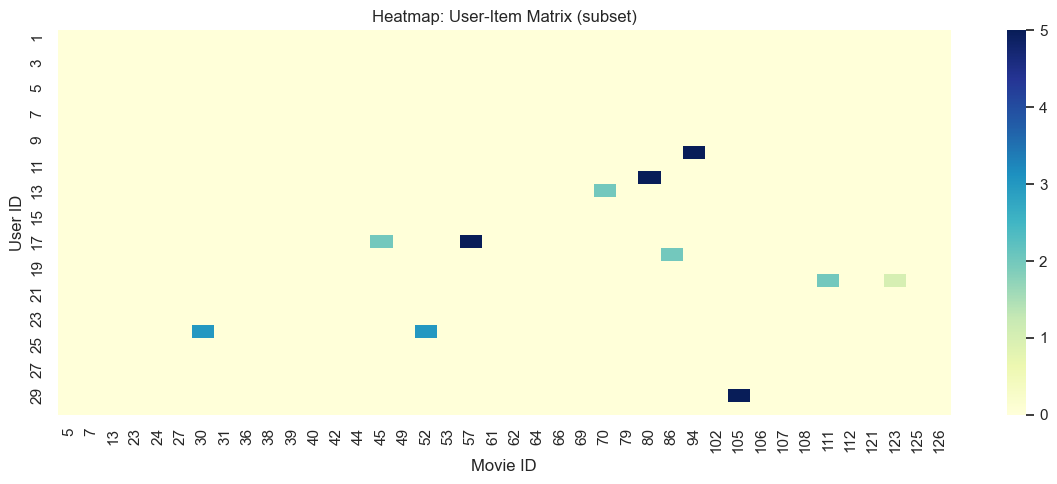

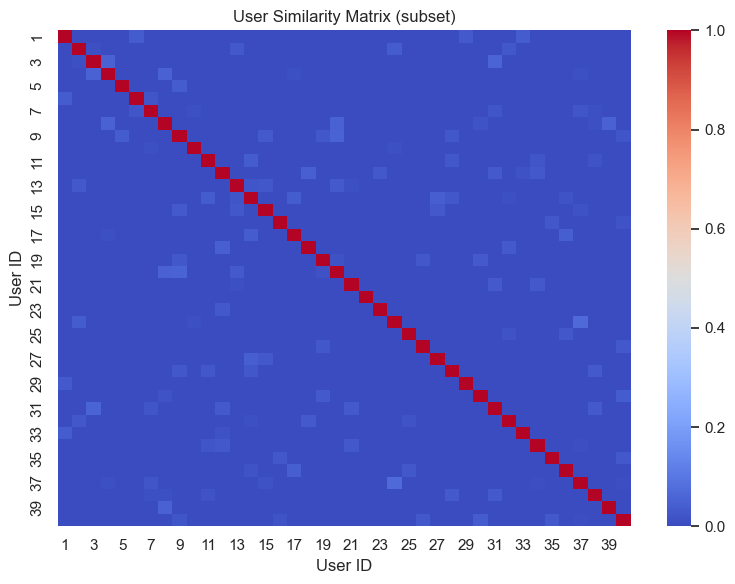

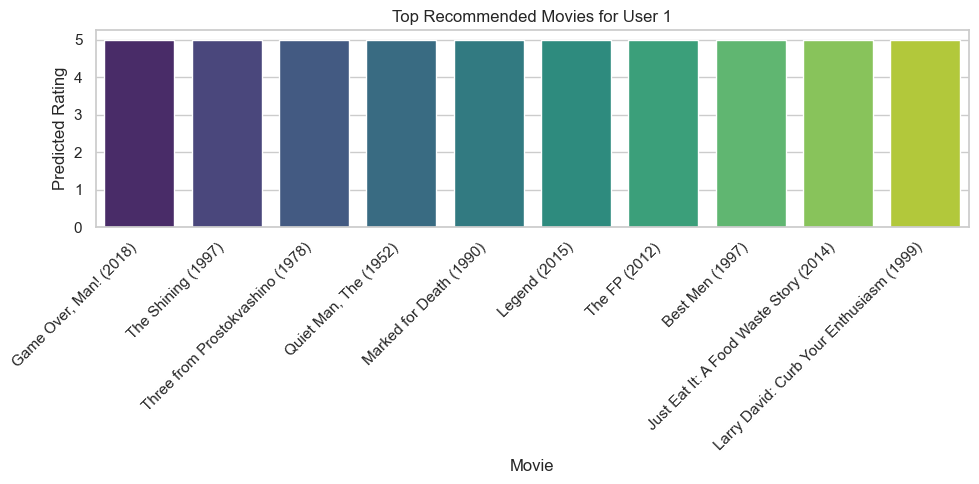

In [28]:
# 10) Visualizations
plt.figure(figsize=(12, 5))
subset_users = user_item_train.index[:30]
subset_movies = user_item_train.columns[:40]
heat_data = user_item_train.loc[subset_users, subset_movies].fillna(0)
sns.heatmap(heat_data, cmap="YlGnBu")
plt.title("Heatmap: User-Item Matrix (subset)")
plt.xlabel("Movie ID")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sim_subset = user_similarity_df.iloc[:40, :40]
sns.heatmap(sim_subset, cmap="coolwarm", vmin=0, vmax=1)
plt.title("User Similarity Matrix (subset)")
plt.xlabel("User ID")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

if not recommendations_view.empty:
    plt.figure(figsize=(10, 5))
    plot_df = recommendations_view.copy().head(10)
    labels = plot_df["title"].fillna(plot_df["movieId"].astype(str)) if "title" in plot_df.columns else plot_df["movieId"].astype(str)
    sns.barplot(x=labels, y=plot_df["predicted_rating"], palette="viridis")
    plt.title(f"Top Recommended Movies for User {target_user}")
    plt.xlabel("Movie")
    plt.ylabel("Predicted Rating")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No recommendations available to plot.")

# Scenario 2: Item-Based Collaborative Filtering

## Problem Statement
Recommend similar items based on user ratings/interactions.

## Notes
- Uses the same prepared `ratings_df`, `train_df`, and `test_df` from Scenario 1.
- Similarity options implemented: **Cosine** and **Pearson**.
- Evaluation: **RMSE** and **Precision@K**.
- Includes side-by-side comparison with Scenario 1 (user-based CF).

In [32]:
# S2-1) Build item-user matrix and compute item similarities
item_user_train = train_df.pivot_table(index="movieId", columns="userId", values="rating", aggfunc="mean")
item_user_filled = item_user_train.fillna(0)

# Cosine similarity between items
item_similarity_cos = cosine_similarity(item_user_filled)
item_similarity_cos_df = pd.DataFrame(
    item_similarity_cos,
    index=item_user_filled.index,
    columns=item_user_filled.index,
)

# Pearson similarity between items (keeps NaN unrated structure)
item_similarity_pearson_df = item_user_train.T.corr(method="pearson", min_periods=2).fillna(0)

# Choose similarity method: "cosine" or "pearson"
item_similarity_method = "cosine"
item_similarity_df = item_similarity_cos_df if item_similarity_method == "cosine" else item_similarity_pearson_df

print("Item-User matrix shape:", item_user_train.shape)
print("Item similarity matrix shape:", item_similarity_df.shape)
item_user_sparsity = 1 - (item_user_train.notna().sum().sum() / (item_user_train.shape[0] * item_user_train.shape[1]))
print(f"Item-User matrix sparsity: {item_user_sparsity*100:.2f}%")

Item-User matrix shape: (3181, 120)
Item similarity matrix shape: (3181, 3181)
Item-User matrix sparsity: 98.99%


In [39]:
# S2-2) Top similar items and item-based recommendation functions
def get_top_n_similar_items(target_item, similarity_df, n_neighbors=10):
    if target_item not in similarity_df.index:
        return pd.Series(dtype=float)
    sims = similarity_df.loc[target_item].drop(index=target_item)
    return sims.sort_values(ascending=False).head(n_neighbors)


def predict_rating_item_based(user_id, movie_id, user_item, item_similarity):
    if (user_id not in user_item.index) or (movie_id not in item_similarity.index):
        return np.nan

    user_ratings = user_item.loc[user_id].dropna()
    seen_items = [i for i in user_ratings.index if i in item_similarity.index and i != movie_id]
    if len(seen_items) == 0:
        return np.nan

    sims = item_similarity.loc[movie_id, seen_items]
    ratings = user_ratings.loc[seen_items]
    denom = np.abs(sims).sum()
    if denom == 0:
        return np.nan

    return float((sims * ratings).sum() / denom)


def recommend_top_n_item_based(
    user_id,
    user_item,
    item_similarity,
    n_recommendations=10,
    candidate_pool_size=120,
):
    if user_id not in user_item.index:
        return pd.DataFrame(columns=["movieId", "predicted_rating_item"])

    user_ratings = user_item.loc[user_id].dropna()
    seen_items = [i for i in user_ratings.index if i in item_similarity.index]
    if len(seen_items) == 0:
        return pd.DataFrame(columns=["movieId", "predicted_rating_item"])

    # Fast candidate generation: items most related to user's seen items
    sim_strength = item_similarity[seen_items].abs().sum(axis=1)
    sim_strength = sim_strength.drop(index=seen_items, errors="ignore")
    candidates = sim_strength.sort_values(ascending=False).head(candidate_pool_size).index.tolist()
    if len(candidates) == 0:
        return pd.DataFrame(columns=["movieId", "predicted_rating_item"])

    sims_mat = item_similarity.loc[candidates, seen_items]
    ratings_vec = user_ratings.loc[seen_items].values

    num = sims_mat.values.dot(ratings_vec)
    den = np.abs(sims_mat.values).sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        preds = np.where(den > 0, num / den, np.nan)

    rec = pd.DataFrame({"movieId": candidates, "predicted_rating_item": preds})
    rec = rec.dropna(subset=["predicted_rating_item"])
    return rec.sort_values("predicted_rating_item", ascending=False).head(n_recommendations)

# Demo: top similar items for first recommended movie (fallback to first matrix item)
demo_item = int(recommendations["movieId"].iloc[0]) if len(recommendations) else int(item_similarity_df.index[0])
print("Demo item:", demo_item)
get_top_n_similar_items(demo_item, item_similarity_df, n_neighbors=10).head(10)

Demo item: 185435


movieId
1683     1.0
2271     1.0
4709     1.0
1171     1.0
5499     1.0
4600     1.0
8582     1.0
8690     1.0
8743     1.0
32649    1.0
Name: 185435, dtype: float64

In [40]:
# S2-3) Item-based recommendations for target user + evaluation (RMSE, Precision@K)
user_rmse_baseline = rmse if "rmse" in globals() else np.nan
user_mae_baseline = mae if "mae" in globals() else np.nan

item_recommendations = recommend_top_n_item_based(
    target_user,
    user_item_train,
    item_similarity_df,
    n_recommendations=10,
    candidate_pool_size=120,
)
print(f"Item-based top recommendations for user {target_user}:")
item_recommendations

# RMSE/MAE for item-based
item_preds, item_trues = [], []
for row in test_df.itertuples(index=False):
    u, m, true_r = int(row.userId), int(row.movieId), float(row.rating)
    pred_r = predict_rating_item_based(u, m, user_item_train, item_similarity_df)
    if not np.isnan(pred_r):
        item_preds.append(pred_r)
        item_trues.append(true_r)

if len(item_preds) > 0:
    item_rmse = mean_squared_error(item_trues, item_preds) ** 0.5
    item_mae = mean_absolute_error(item_trues, item_preds)
else:
    item_rmse, item_mae = np.nan, np.nan

# Precision@K for item-based (user limit keeps lab runtime predictable)
def precision_at_k_item(
    test_data,
    user_item,
    item_similarity,
    k=10,
    threshold=4.0,
    candidate_pool_size=120,
    max_users=60,
):
    users = sorted(set(test_data["userId"]).intersection(set(user_item.index)))
    users = users[:max_users]
    precisions = []

    for u in users:
        true_rel = set(test_data[(test_data["userId"] == u) & (test_data["rating"] >= threshold)]["movieId"])
        if len(true_rel) == 0:
            continue

        rec_u = recommend_top_n_item_based(
            u,
            user_item,
            item_similarity,
            n_recommendations=k,
            candidate_pool_size=candidate_pool_size,
        )
        rec_items = set(rec_u["movieId"].tolist())
        if len(rec_items) == 0:
            continue

        precisions.append(len(rec_items.intersection(true_rel)) / k)

    return float(np.mean(precisions)) if len(precisions) > 0 else np.nan

item_precision_k = precision_at_k_item(
    test_df,
    user_item_train,
    item_similarity_df,
    k=10,
    threshold=4.0,
    candidate_pool_size=120,
    max_users=60,
)

print(f"Item-based RMSE: {item_rmse:.4f}" if not np.isnan(item_rmse) else "Item-based RMSE: NaN")
print(f"Item-based MAE : {item_mae:.4f}" if not np.isnan(item_mae) else "Item-based MAE : NaN")
print(f"Item-based Precision@10: {item_precision_k:.4f}" if not np.isnan(item_precision_k) else "Item-based Precision@10: NaN")

Item-based top recommendations for user 1:
Item-based RMSE: 1.7029
Item-based MAE : 1.3000
Item-based Precision@10: 0.0000


In [41]:
# S2-4) Comparison analysis: item-based vs user-based + popular vs niche
# User-based Precision@K (for fair comparison; user limit keeps runtime manageable)
def precision_at_k_user(test_data, user_item, similarity_df, k=10, threshold=4.0, n_neighbors=10, max_users=20):
    users = sorted(set(test_data["userId"]).intersection(set(user_item.index)))
    users = users[:max_users]
    precisions = []

    for u in users:
        true_rel = set(test_data[(test_data["userId"] == u) & (test_data["rating"] >= threshold)]["movieId"])
        if len(true_rel) == 0:
            continue

        rec_u = recommend_top_n(u, user_item, similarity_df, n_recommendations=k, n_neighbors=n_neighbors)
        rec_items = set(rec_u["movieId"].tolist())

        if len(rec_items) == 0:
            continue

        precisions.append(len(rec_items.intersection(true_rel)) / k)

    return float(np.mean(precisions)) if len(precisions) > 0 else np.nan

user_precision_k = precision_at_k_user(test_df, user_item_train, user_similarity_df, k=10, threshold=4.0, n_neighbors=10, max_users=20)

# Popular vs niche items from training interactions
item_popularity = train_df.groupby("movieId").size().rename("interaction_count").sort_values(ascending=False)
popular_cut = int(np.percentile(item_popularity.values, 75)) if len(item_popularity) else 0
niche_cut = int(np.percentile(item_popularity.values, 25)) if len(item_popularity) else 0

popular_items = item_popularity[item_popularity >= popular_cut]
niche_items = item_popularity[item_popularity <= niche_cut]

print("Scenario comparison:")
print(f"User-based RMSE      : {user_rmse_baseline:.4f}" if not np.isnan(user_rmse_baseline) else "User-based RMSE      : NaN")
print(f"Item-based RMSE      : {item_rmse:.4f}" if not np.isnan(item_rmse) else "Item-based RMSE      : NaN")
print(f"User-based Precision@10: {user_precision_k:.4f}" if not np.isnan(user_precision_k) else "User-based Precision@10: NaN")
print(f"Item-based Precision@10: {item_precision_k:.4f}" if not np.isnan(item_precision_k) else "Item-based Precision@10: NaN")

print("\nPopular vs niche items:")
print("Popular items count:", len(popular_items), "(>= 75th percentile interactions)")
print("Niche items count  :", len(niche_items), "(<= 25th percentile interactions)")

print("\nScalability note:")
print("Item-based CF precomputes an item-item matrix; inference is often faster for active users,")
print("but matrix size scales roughly with number of items squared.")

Scenario comparison:
User-based RMSE      : 1.1597
Item-based RMSE      : 1.7029
User-based Precision@10: 0.0000
Item-based Precision@10: 0.0000

Popular vs niche items:
Popular items count: 3181 (>= 75th percentile interactions)
Niche items count  : 2603 (<= 25th percentile interactions)

Scalability note:
Item-based CF precomputes an item-item matrix; inference is often faster for active users,
but matrix size scales roughly with number of items squared.


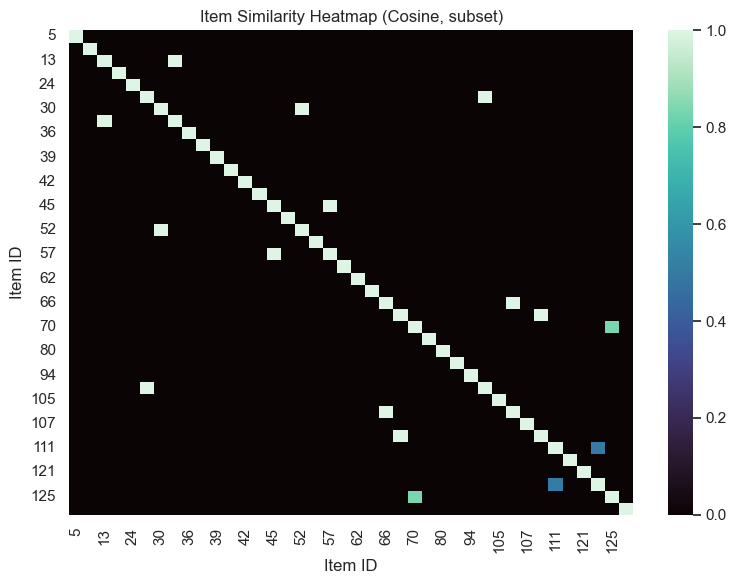

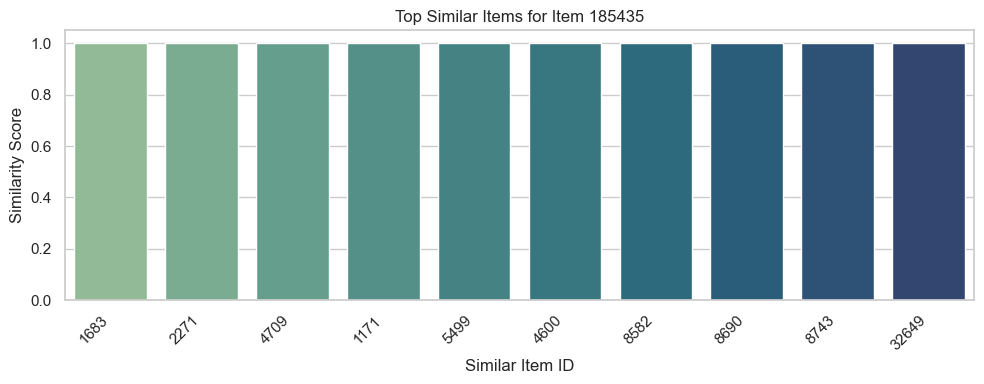

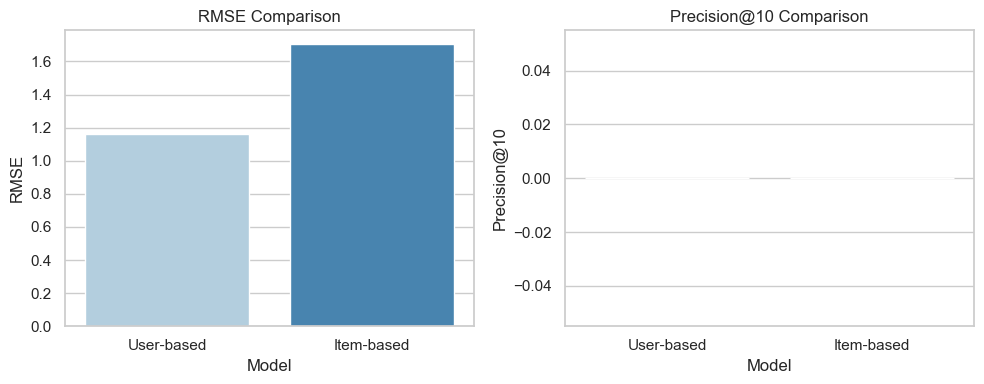

In [42]:
# S2-5) Visualizations for Scenario 2
# (a) Item similarity heatmap (subset)
plt.figure(figsize=(8, 6))
item_subset_ids = item_similarity_df.index[:40]
item_sim_subset = item_similarity_df.loc[item_subset_ids, item_subset_ids]
sns.heatmap(item_sim_subset, cmap="mako", vmin=0 if item_similarity_method == "cosine" else None, vmax=1 if item_similarity_method == "cosine" else None)
plt.title(f"Item Similarity Heatmap ({item_similarity_method.title()}, subset)")
plt.xlabel("Item ID")
plt.ylabel("Item ID")
plt.tight_layout()
plt.show()

# (b) Top similar items graph for demo item
top_sim_items = get_top_n_similar_items(demo_item, item_similarity_df, n_neighbors=10)
if len(top_sim_items) > 0:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=top_sim_items.index.astype(str), y=top_sim_items.values, palette="crest")
    plt.title(f"Top Similar Items for Item {demo_item}")
    plt.xlabel("Similar Item ID")
    plt.ylabel("Similarity Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No similar items available for plotting.")

# (c) Recommendation comparison chart (user-based vs item-based)
comparison_metrics = pd.DataFrame(
    {
        "Model": ["User-based", "Item-based"],
        "RMSE": [user_rmse_baseline, item_rmse],
        "Precision@10": [user_precision_k, item_precision_k],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=comparison_metrics, x="Model", y="RMSE", palette="Blues", ax=axes[0])
axes[0].set_title("RMSE Comparison")

sns.barplot(data=comparison_metrics, x="Model", y="Precision@10", palette="Greens", ax=axes[1])
axes[1].set_title("Precision@10 Comparison")

plt.tight_layout()
plt.show()